In [2]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

text = "The cats are running quickly in the garden."

tokens = word_tokenize(text.lower())

stop_words = set(stopwords.words('english'))
filtered_words = [word for word in tokens if word.isalpha() and word not in stop_words]

lemmatizer = WordNetLemmatizer()
processed_words = [lemmatizer.lemmatize(word) for word in filtered_words]

print(processed_words)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


['cat', 'running', 'quickly', 'garden']


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

texts = [
    "I love this movie",
    "This film is amazing",
    "I hate this movie",
    "Terrible film"
]

labels = [1, 1, 0, 0]

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.25, random_state=42
)

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

predictions = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.0


In [4]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

vocab_size = 10000
maxlen = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

model = Sequential([
    Embedding(vocab_size, 16, input_length=maxlen),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=512,
    validation_split=0.2
)

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5976 - loss: 0.6906 - val_accuracy: 0.6870 - val_loss: 0.6850
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6923 - loss: 0.6772 - val_accuracy: 0.7498 - val_loss: 0.6635
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7506 - loss: 0.6450 - val_accuracy: 0.7738 - val_loss: 0.6189
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7810 - loss: 0.5908 - val_accuracy: 0.7988 - val_loss: 0.5578
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8142 - loss: 0.5237 - val_accuracy: 0.8104 - val_loss: 0.4944
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8093 - loss: 0.4995
Test Accuracy: 0.8093199729919434


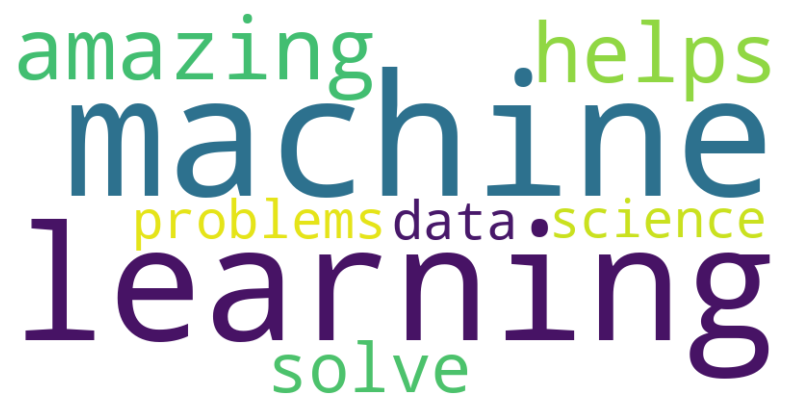

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = """
machine learning is amazing
machine learning helps solve problems
data science and machine learning
"""

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()